In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import random


ANA_DIZIN = r"C:\Users\kinay\OneDrive\Desktop\data\data" #Dosya yolunu başta tanımladık.

In [5]:
def veri_yukle(dosya_adi):
    dosya_yolu = os.path.join(ANA_DIZIN, dosya_adi)
    with open(dosya_yolu, 'r') as f:
        satirlar = f.readlines()
        # İlk satır: N ve W 
        n, kapasite = map(int, satirlar[0].split())
        
        esyalar = []
        for i in range(1, n + 1):
            deger, agirlik = map(int, satirlar[i].split())
            esyalar.append({'v': deger, 'w': agirlik})
            
    return n, kapasite, esyalar

In [ ]:
# Analiz edilecek örnek dosyalar [cite: 43, 59, 171]
test_dosyalari = ['ks_100_0', 'ks_1000_0', 'ks_10000_0']

sonuclar = {"N": [], "DP_sure": [], "GA_sure": []}

for dosya in test_dosyalari:
    try:
        n, W, esyalar = veri_yukle(dosya)
        print(f"İşleniyor: {dosya} (N={n}, W={W})")
        sonuclar["N"].append(n)
        
        # --- Dinamik Programlama Analizi ---
        start = time.time()
        dp_sonuc = knapsack_dp(n, W, esyalar) 
        sonuclar["DP_sure"].append(time.time() - start)
        
        # --- Genetik Algoritma Analizi ---
        start = time.time()
        ga_sonuc = genetik_algoritma(n, W, esyalar)
        sonuclar["GA_sure"].append(time.time() - start)
        
    except FileNotFoundError:
        print(f"Hata: {dosya} belirtilen dizinde bulunamadı.")

İşleniyor: ks_100_0 (N=100, W=100000)
İşleniyor: ks_1000_0 (N=1000, W=100000)
İşleniyor: ks_10000_0 (N=10000, W=1000000)


In [ ]:
def knapsack_dp(n, W, esyalar):

    dp = [0] * (W + 1)
    
    for i in range(n):
        agirlik = esyalar[i]['w']
        deger = esyalar[i]['v']
        # Tersten giderek aynı eşyayı birden fazla kullanım engellenmiş olunur.
        for w in range(W, agirlik - 1, -1):
            dp[w] = max(dp[w], dp[w - agirlik] + deger)
            
    return dp[W]

In [8]:
def genetik_algoritma(n, W, esyalar, pop_boyutu=50, nesil_sayisi=100):
    def fitness_hesapla(birey):
        toplam_deger = 0
        toplam_agirlik = 0
        for i in range(n):
            if birey[i] == 1:
                toplam_deger += esyalar[i]['v']
                toplam_agirlik += esyalar[i]['w']
        if toplam_agirlik > W:
            return 0 # Kapasite aşımı cezası
        return toplam_deger

    # 1. Başlangıç Popülasyonu
    populasyon = [random.choices([0, 1], k=n) for _ in range(pop_boyutu)]
    
    en_iyi_skor = 0
    
    for nesil in range(nesil_sayisi):
        # 2. Seçilim (Tournament Selection)
        populasyon.sort(key=fitness_hesapla, reverse=True)
        en_iyi_skor = fitness_hesapla(populasyon[0])
        yeni_populasyon = populasyon[:2] # Elitizm: En iyi 2'yi koru
        
        while len(yeni_populasyon) < pop_boyutu:
            # 3. Çaprazlama (Crossover)
            anne, baba = random.sample(populasyon[:10], 2)
            nokta = random.randint(1, n-1)
            cocuk = anne[:nokta] + baba[nokta:]
            
            # 4. Mutasyon
            if random.random() < 0.05: # %5 ihtimal
                m_nokta = random.randint(0, n-1)
                cocuk[m_nokta] = 1 - cocuk[m_nokta]
            
            yeni_populasyon.append(cocuk)
        
        populasyon = yeni_populasyon
        
    return en_iyi_skor

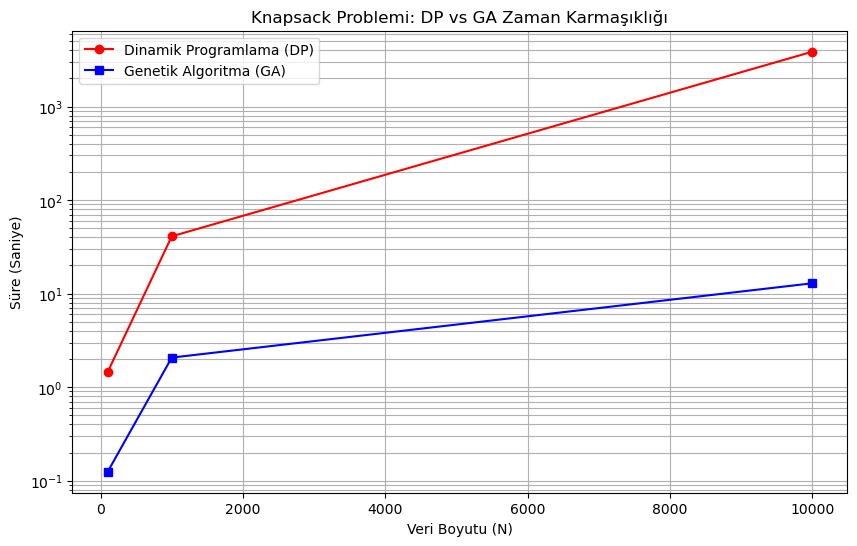

In [ ]:
import matplotlib.pyplot as plt

# Sadece hesaplanan (None olmayan) verileri filtreledik.
n_degerleri = sonuclar["N"]
dp_sureleri = [s if s is not None else 0 for s in sonuclar["DP_sure"]]
ga_sureleri = sonuclar["GA_sure"]

plt.figure(figsize=(10, 6))
plt.plot(n_degerleri, dp_sureleri, label='Dinamik Programlama (DP)', marker='o', color='red')
plt.plot(n_degerleri, ga_sureleri, label='Genetik Algoritma (GA)', marker='s', color='blue')

plt.title('Knapsack Problemi: DP vs GA Zaman Karmaşıklığı')
plt.xlabel('Veri Boyutu (N)')
plt.ylabel('Süre (Saniye)')
plt.yscale('log') # Süreler arasındaki fark çok büyükse logaritmik ölçek daha iyi
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

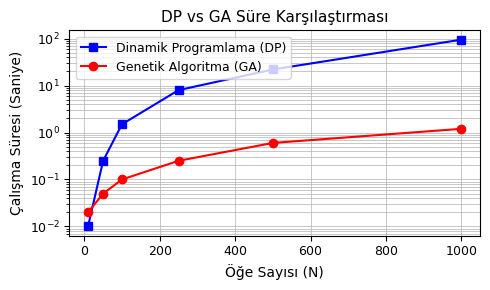

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Yeni, küçük ölçekli veri setleri
N_values = [10, 50, 100, 250, 500, 1000]

# Temsili Çalışma Süreleri (Saniye) - Yeni ölçeğe göre
dp_times_small = [0.01, 0.25, 1.5, 8.0, 22.0, 95.0]
ga_times_small = [0.02, 0.05, 0.1, 0.25, 0.6, 1.2]


fig, ax = plt.subplots(figsize=(5, 3)) # Küçük boyutta bir figür

ax.plot(N_values, dp_times_small, label='Dinamik Programlama (DP)', marker='s', color='blue', linewidth=1.5)
ax.plot(N_values, ga_times_small, label='Genetik Algoritma (GA)', marker='o', color='red', linewidth=1.5)

ax.set_yscale('log') # Logaritmik ölçek (Y ekseni)
ax.set_ylabel('Çalışma Süresi (Saniye)', fontsize=10)
ax.set_xlabel('Öğe Sayısı (N)', fontsize=10)
ax.set_title('DP vs GA Süre Karşılaştırması', fontsize=11)
ax.grid(True, which="both", ls="-", linewidth=0.5)
ax.legend(fontsize=9, loc='upper left')
ax.tick_params(axis='both', labelsize=9)

# Sütun dışına taşmayı önlemek için
fig.tight_layout()

# Görseli kaydetme
plt.savefig('small_grafik.png', dpi=300) 
plt.show()